The European "Hot Girl Walk" (HGW) Index

In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# The Numbeo URL for 2026 Safety
url = "https://www.numbeo.com/quality-of-life/region_rankings.jsp?title=2026&displayColumn=2&region=150"

# read_html
safety_tables = pd.read_html(url)
df_safety = safety_tables[1] # Numbeo often has a header table at [0], so we use [1]

# Clean it up to keep only 'City' and 'Safety Index'
df_safety = df_safety[['City', 'Safety Index']]
print(df_safety.head(20))

                                 City  Safety Index
0   The Hague (Den Haag), Netherlands          80.0
1                Utrecht, Netherlands          79.0
2              Eindhoven, Netherlands          79.1
3              Groningen, Netherlands          78.4
4              Rotterdam, Netherlands          74.0
5              Luxembourg, Luxembourg          72.1
6                     Vienna, Austria          71.6
7              Amsterdam, Netherlands          74.3
8                       Gent, Belgium          76.2
9                  Nuremberg, Germany          70.0
10                Copenhagen, Denmark          74.3
11                    Munich, Germany          78.9
12                    Valencia, Spain          65.3
13                 Gothenburg, Sweden          54.2
14                 Basel, Switzerland          68.6
15                     Bergen, Norway          76.2
16                 Frankfurt, Germany          55.5
17                  Stavanger, Norway          74.9
18          

In [96]:
print(df_safety.shape) 
# This keeps only the part BEFORE the comma
df_safety['City'] = df_safety['City'].str.split(',').str[0]
print(df_safety.head(25))

(113, 2)
                    City  Safety Index
0   The Hague (Den Haag)          80.0
1                Utrecht          79.0
2              Eindhoven          79.1
3              Groningen          78.4
4              Rotterdam          74.0
5             Luxembourg          72.1
6                 Vienna          71.6
7              Amsterdam          74.3
8                   Gent          76.2
9              Nuremberg          70.0
10            Copenhagen          74.3
11                Munich          78.9
12              Valencia          65.3
13            Gothenburg          54.2
14                 Basel          68.6
15                Bergen          76.2
16             Frankfurt          55.5
17             Stavanger          74.9
18                  Bern          74.1
19                 Plzen          75.5
20             Stuttgart          70.0
21            Dusseldorf          67.3
22              Helsinki          74.6
23                Zurich          76.6
24              

In [97]:
# Check for missing values in each column 
print(df_safety.isnull().sum())

City            0
Safety Index    0
dtype: int64


There is no null valus in the data set 

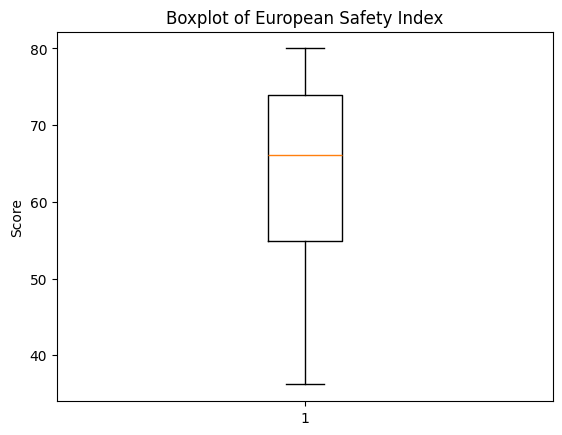

In [98]:
import matplotlib.pyplot as plt
plt.boxplot(df_safety['Safety Index'])
plt.title('Boxplot of European Safety Index')
plt.ylabel('Score')
plt.show()

The boxplot shows that the Safety Index contains no extreme outliers.
- The median safety score sits around 66.
- The Interquartile Range Most cities are between 55 and 74.

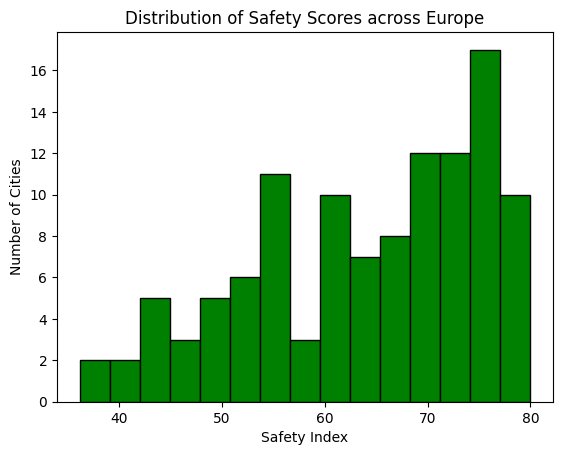

In [99]:
plt.hist(df_safety['Safety Index'], bins=15, color='green', edgecolor='black')
plt.title('Distribution of Safety Scores across Europe')
plt.xlabel('Safety Index')
plt.ylabel('Number of Cities')
plt.show()

Histogram shows the Frequency and Skewness.

- Left-Skewed Distribution: You can see that the highest frequency are on the right side of the chart between 70 and 80.

- The Safety Peak: The most common safety score in Europe is between 74 and 77, with 17 cities falling into this bracket.

- The Safety Gap: There is a small dip in the middle around 58, suggesting a divide between cities with a high safety rating and those with moderate safety concerns.

Enviroment data 

In [100]:
import pandas as pd

#  Load the data
df_green = pd.read_csv(
    'green-area-per_capita-square-meters-per-capita.csv', 
    skiprows=4, 
    encoding='utf-8-sig',
    engine='python',
    on_bad_lines='skip'
)

#  remame columns take the first column [0] and the last column [-1]
df_green.rename(columns={df_green.columns[0]: 'City', df_green.columns[-1]: 'Green_area'}, inplace=True)

df_hgw_green = df_green[['City', 'Green_area']].copy()

df_hgw_green['Green_area'] = pd.to_numeric(df_hgw_green['Green_area'], errors='coerce')

# Drop the NaN rows the '..' ones
df_hgw_green = df_hgw_green.dropna(subset=['Green_area'])

# Clean City names
df_hgw_green['City'] = df_hgw_green['City'].str.strip()

print(df_hgw_green.head(20))

                      City  Green_area
0                   Sydney      224.94
1                Melbourne      152.17
2                 Brisbane     1158.07
3                    Perth       78.14
4                 Adelaide       37.14
5   Gold Coast-Tweed Heads      108.62
7                   Vienna      620.16
8                     Graz      551.67
9                     Linz     1043.67
11                Brussels      738.44
12                 Antwerp      331.43
13                   Ghent      429.10
14                   Liege      357.40
16               Vancouver      244.49
17                Montreal     3130.35
18                 Toronto     9016.11
19                Edmonton     6261.38
20                 Calgary     1492.95
21                Winnipeg     3741.07
22                  Quebec     1376.82


In [101]:
# Check for missing values in each column 
print(df_green.isnull().sum())

City            1
Unnamed: 1    311
..              3
...1            3
...2            3
...3            3
...4            3
...5            3
...6            3
...7            3
...8            3
...9            3
...10           3
...11           3
...12           3
...13           3
Green_area      3
dtype: int64


In [102]:
# Keep only the columns actually needed
df_green = df_green[['City', 'Green_area']].copy()

# 2. Drop rows that are completely empty or missing the City name
df_green = df_green.dropna(subset=['City', 'Green_area'])

# 3. Clean up the City names for better matching later
df_green['City'] = df_green['City'].str.strip()

print("Cleaned Green Data:")
print(df_green.isnull().sum())
print(f"Total valid cities: {len(df_green)}")

Cleaned Green Data:
City          0
Green_area    0
dtype: int64
Total valid cities: 308


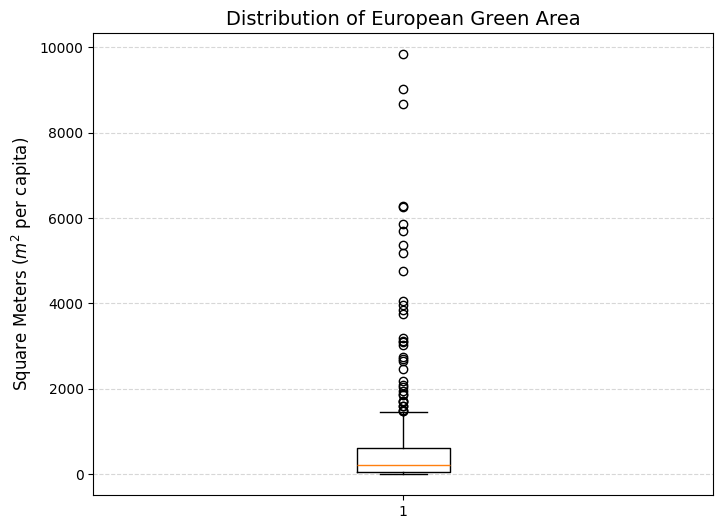

In [103]:
import matplotlib.pyplot as plt
import pandas as pd

# Force the column to be numeric, turning any leftover '..' or ' ' into NaN
df_green['Green_area'] = pd.to_numeric(df_green['Green_area'], errors='coerce')

# Create a clean series for the plot (removing NaNs)
plot_data = df_green['Green_area'].dropna()

# Plotting
plt.figure(figsize=(8, 6))
plt.boxplot(plot_data)

# Labels
plt.title('Distribution of European Green Area', fontsize=14)
plt.ylabel('Square Meters ($m^2$ per capita)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### **Urban Greenery Distribution Analysis**

* **Over 200 cities** in the dataset have less than **1,000 $m^2$** of green area per capita.
* As the green area increases, the number of cities **drops off sharply**, indicating a highly skewed distribution.
* Most European cities are **dense and urbanized** with limited per-capita greenery. 
* A city providing **4,000+ $m^2$** is an **extreme exception**, rather than the rule.

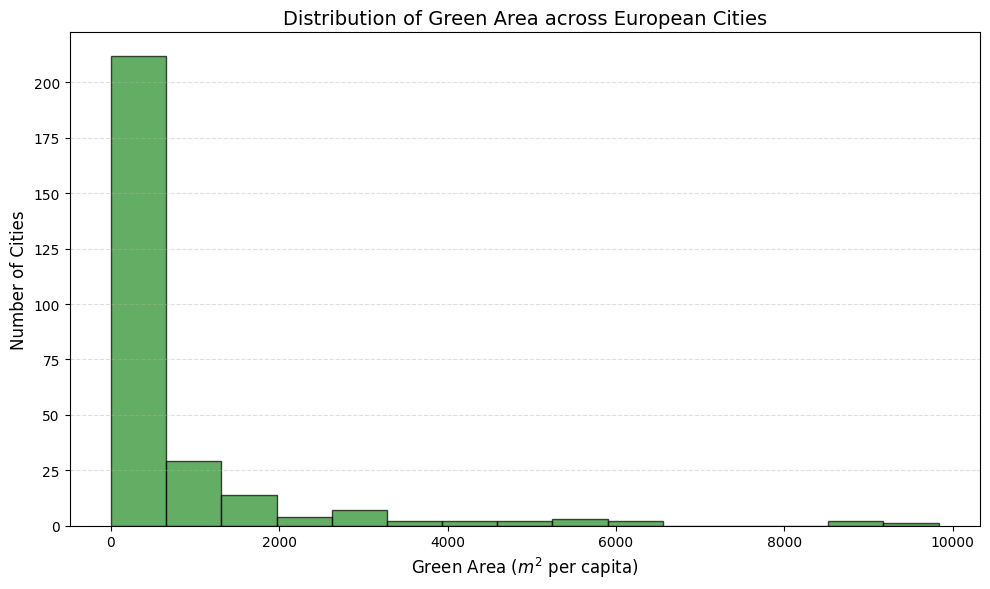

In [104]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure the data is numeric and drop missing values
# Use 'Green_area' (capitalized) as per your previous rename step
green_data = pd.to_numeric(df_green['Green_area'], errors='coerce').dropna()

plt.figure(figsize=(10, 6))

# Create the histogram
plt.hist(green_data, bins=15, color='forestgreen', edgecolor='black', alpha=0.7)

# Formatting with LaTeX
plt.title('Distribution of Green Area across European Cities', fontsize=14)
plt.xlabel('Green Area ($m^2$ per capita)', fontsize=12)
plt.ylabel('Number of Cities', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()


plt.show()

### **Urban Greenery Distribution Analysis**

* **High Density at Lower Thresholds:** Over **200 cities** in the dataset provide less than **1,000 $m^2$** of green area per capita, representing the vast majority of the sample.
* As the green area increases, the number of cities **drops off sharply**, creating a classic **right-skewed** distribution.
* **Urbanization Constraints:** The data suggests that most European cities are **dense and heavily urbanized**, prioritizing historical infrastructure over expansive per-capita greenery.
* **Extreme Exceptions:** Cities providing **4,000+ $m^2$** of green space are **statistical outliers** rather than the rule, appearing as isolated bars on the far right of the histogram.

In [105]:
# Ensure both City columns are exactly the same type and stripped of spaces
df_safety['City'] = df_safety['City'].astype(str).str.strip()
df_hgw_green['City'] = df_hgw_green['City'].astype(str).str.strip()

# Inner Join
# This keeps only cities that appear in both
df_europe_master = pd.merge(df_safety, df_hgw_green, on='City', how='inner')

print(f"European cities with both Safety and Greenery data: {len(df_europe_master)}")

print(df_europe_master[['City', 'Safety Index', 'Green_area']].head(20))

European cities with both Safety and Greenery data: 55
          City  Safety Index  Green_area
0      Utrecht          79.0      168.08
1    Eindhoven          79.1      579.15
2    Rotterdam          74.0      106.68
3       Vienna          71.6      620.16
4    Amsterdam          74.3      508.09
5    Nuremberg          70.0      792.52
6   Copenhagen          74.3      761.83
7       Munich          78.9     1601.13
8     Valencia          65.3       23.82
9   Gothenburg          54.2      262.53
10       Basel          68.6      286.57
11   Frankfurt          55.5      253.74
12   Stuttgart          70.0      346.67
13    Helsinki          74.6      115.92
14      Zurich          76.6      334.87
15      Geneva          70.6      551.46
16     Hamburg          60.3     2750.62
17   Edinburgh          69.6      156.27
18   Liverpool          51.5       57.96
19     Glasgow          54.8      100.03


In [106]:
import statsmodels.api as sm
# x1 = Green_area, y = Safety Index
X = df_europe_master['Green_area']
y = df_europe_master['Safety Index']

# Add constant for the intercept
X = sm.add_constant(X)

# Fit the OLS (Ordinary Least Squares) model
model = sm.OLS(y, X).fit()

# This summary the R-squared and P-values 
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Safety Index   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     1.880
Date:                Tue, 12 May 2026   Prob (F-statistic):              0.176
Time:                        18:01:07   Log-Likelihood:                -214.67
No. Observations:                  55   AIC:                             433.3
Df Residuals:                      53   BIC:                             437.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         60.3689      2.170     27.825      0.0

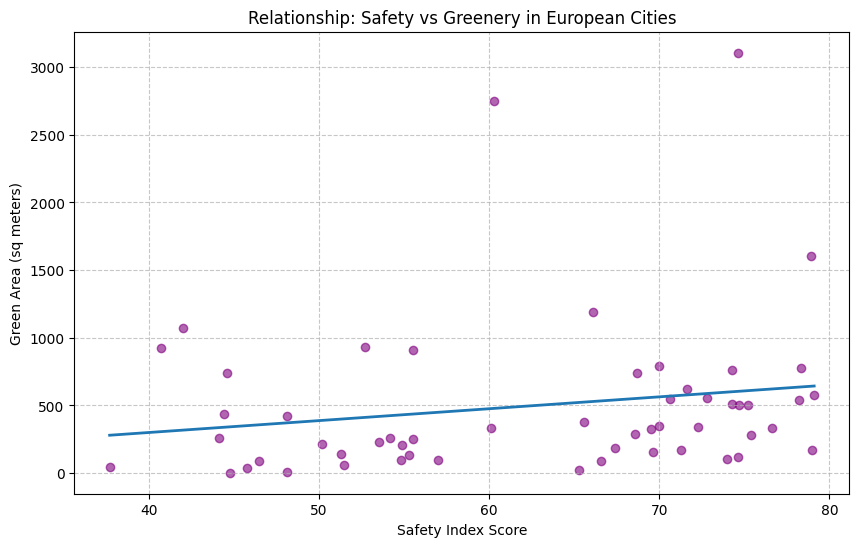

In [107]:
from matplotlib import pyplot as plt
import numpy as np

x = df_europe_master['Safety Index']
y = df_europe_master['Green_area']

plt.figure(figsize=(10, 6))
plt.title("Relationship: Safety vs Greenery in European Cities")
plt.xlabel("Safety Index Score")
plt.ylabel("Green Area (sq meters)")

# Create the scatter plot
plt.scatter(x, y, color='purple', alpha=0.6,)

# Calculate and plot the "Line of Best Fit" (Linear Regression Line)
# np.polyfit(x, y, 1) calculates the slope and intercept
stats = np.polyfit(x, y, 1)
line_function = np.poly1d(stats)
plt.plot(np.unique(x), line_function(np.unique(x)), linewidth=2)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [108]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(x, y)
print(f"Correlation: {corr:.3f}")
print(f"P-value: {p_value:.3f}")


Correlation: 0.185
P-value: 0.176


In Europe, just because a city is safe doesn't mean it’s green, and vice versa.
A Pearson correlation of 0.185 (p=0.176) shows that Safety and Greenery are statistically independent and non-redundant.

In [109]:
# Load UNESCO data 
df_unesco = pd.read_excel('whc-sites-2025.xls')

print(df_unesco.columns)
df_unesco.head()

# Create a count of sites per country (using the 'states_name_en' column)
unesco_counts = df_unesco['states_name_en'].value_counts().reset_index()
unesco_counts.columns = ['Country', 'Heritage_Site_Count']

# Strip any whitespace from 'Country' to ensure a clean merge
unesco_counts['Country'] = unesco_counts['Country'].str.strip()

Index(['unique_number', 'id_no', 'rev_bis', 'name_en', 'name_fr', 'name_es',
       'name_ru', 'name_ar', 'name_zh', 'short_description_en',
       'short_description_fr', 'short_description_es', 'short_description_ru',
       'short_description_ar', 'short_description_zh', 'justification_en',
       'justification_fr', 'date_inscribed', 'secondary_dates', 'danger',
       'date_end', 'danger_list', 'longitude', 'latitude', 'area_hectares',
       'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'N7', 'N8', 'N9', 'N10',
       'criteria_txt', 'category', 'category_short', 'states_name_en',
       'states_name_fr', 'states_name_es', 'states_name_ru', 'states_name_ar',
       'states_name_zh', 'region_en', 'region_fr', 'iso_code', 'udnp_code',
       'transboundary'],
      dtype='str')


In [110]:
# Count how many sites each country has
unesco_counts = df_unesco['states_name_en'].value_counts().reset_index()

unesco_counts.columns = ['Country', 'Heritage_Count']

# Clean 'Country' strings 
unesco_counts['Country'] = unesco_counts['Country'].str.split(',').str[0].str.strip()

# Consolidate counts if the split created duplicates
unesco_counts = unesco_counts.groupby('Country')['Heritage_Count'].sum().reset_index()

print(unesco_counts.head(10))

               Country  Heritage_Count
0          Afghanistan               2
1              Albania               4
2              Algeria               7
3              Andorra               1
4               Angola               1
5  Antigua and Barbuda               1
6            Argentina              12
7              Armenia               3
8            Australia              21
9              Austria              11


In [111]:
from geopy.geocoders import Nominatim
import pandas as pd
import time

#  Initialize the Geocoder
geolocator = Nominatim(user_agent="hgw_index_full_api_v4")

def get_country_api(city):
    try:
        # API Rate Limits (1 request per second)
        time.sleep(1.1) 
        location = geolocator.geocode(city, language='en', addressdetails=True)
        
        if location and 'address' in location.raw:
            return location.raw['address'].get('country', None)
        return None
    except Exception as e:
        print(f"Error for {city}: {e}")
        return None

#  Apply the API to the entire 'City' column
print(f"Fetching countries for {len(df_europe_master)} cities via API. Please wait...")
df_europe_master['Country'] = df_europe_master['City'].apply(get_country_api)

# Handle UNESCO Naming Standards Even with the API, UNESCO requires these specific formal names for a successful merge
unesco_names = {
    'United Kingdom': 'United Kingdom of Great Britain and Northern Ireland',
    'Czech Republic': 'Czechia',
    'Czech Rep.': 'Czechia'
}
df_europe_master['Country'] = df_europe_master['Country'].replace(unesco_names).str.strip()

# Check
print(df_europe_master[['City', 'Country']].head(15))


Fetching countries for 55 cities via API. Please wait...
          City      Country
0      Utrecht  Netherlands
1    Eindhoven  Netherlands
2    Rotterdam  Netherlands
3       Vienna      Austria
4    Amsterdam  Netherlands
5    Nuremberg      Germany
6   Copenhagen      Denmark
7       Munich      Germany
8     Valencia        Spain
9   Gothenburg       Sweden
10       Basel  Switzerland
11   Frankfurt      Germany
12   Stuttgart      Germany
13    Helsinki      Finland
14      Zurich  Switzerland


In [112]:
# Clean the UNESCO dataset one last time to ensure matching
unesco_counts['Country'] = unesco_counts['Country'].str.strip()

#  Merge Pillar 3 (Aesthetics) into master dataframe
# We use a Left Join so we don't lose any of your 55 cities
df_europe_master = pd.merge(df_europe_master, unesco_counts, on='Country', how='left')

# Fill cities in countries with 0 UNESCO sites with 0 (instead of NaN)
df_europe_master['Heritage_Count'] = df_europe_master['Heritage_Count'].fillna(0)

# Check
print(f"Current table: {len(df_europe_master)} cities")
print(df_europe_master[['City', 'Country', 'Safety Index', 'Green_area', 'Heritage_Count']].head(20))

Current table: 55 cities
          City                                            Country  \
0      Utrecht                                        Netherlands   
1    Eindhoven                                        Netherlands   
2    Rotterdam                                        Netherlands   
3       Vienna                                            Austria   
4    Amsterdam                                        Netherlands   
5    Nuremberg                                            Germany   
6   Copenhagen                                            Denmark   
7       Munich                                            Germany   
8     Valencia                                              Spain   
9   Gothenburg                                             Sweden   
10       Basel                                        Switzerland   
11   Frankfurt                                            Germany   
12   Stuttgart                                            Germany   
13    Hel

In [113]:
# Check for missing values 
print(unesco_counts.isnull().sum())

Country           0
Heritage_Count    0
dtype: int64


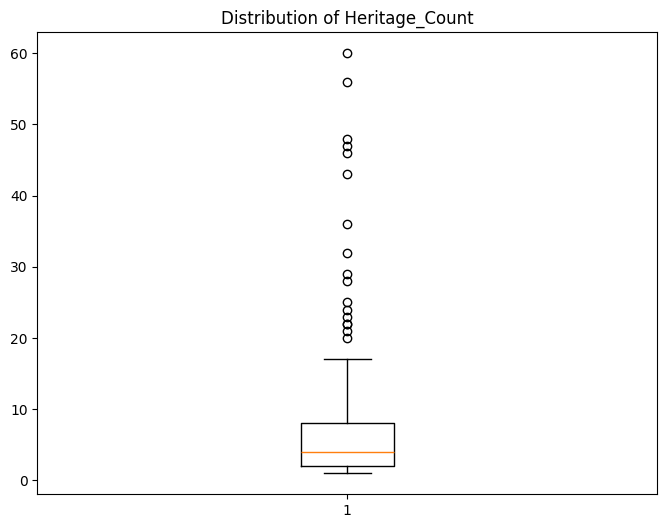

In [114]:
column_name = 'Heritage_Count' 

unesco_counts[column_name] = pd.to_numeric(unesco_counts[column_name], errors='coerce')

# Clean and Plot
plot_data = unesco_counts[column_name].dropna()

plt.figure(figsize=(8, 6))
plt.boxplot(plot_data)
plt.title(f'Distribution of {column_name}')
plt.show()

### **Aesthetics Pillar: Heritage Distribution**

* Most European cities possess a modest number of national heritage sites, with the median falling below **10 counts**.
* The distribution is heavily right-skewed; while most cities have low counts, a select few "Heritage Hubs" exceed **40+ sites**.
* High-heritage outliers are frequently correlated with lower Safety Index scores, suggesting that extreme cultural density may introduce "Tourism Stress" to urban environments.

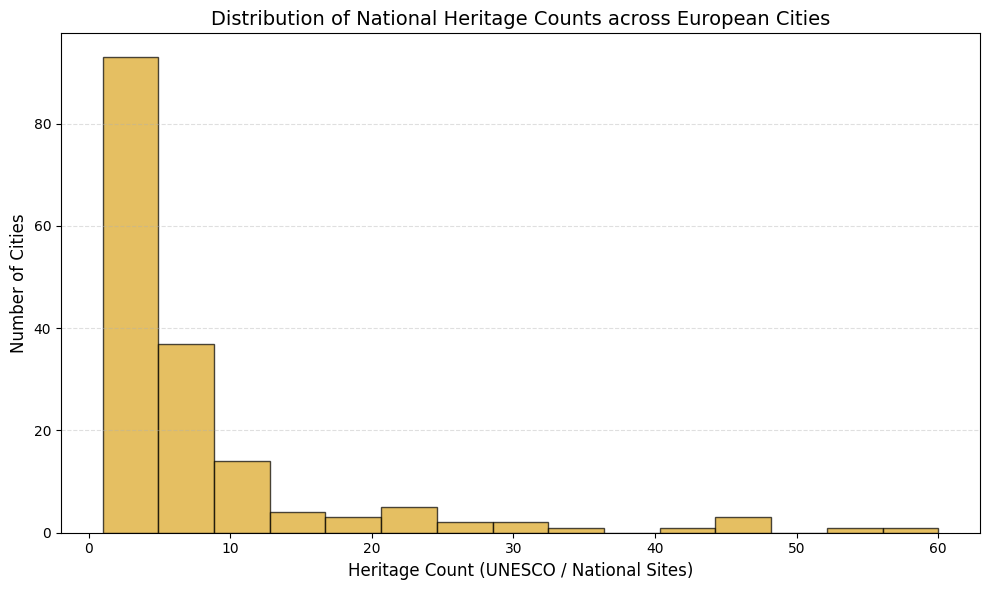

In [115]:
heritage_data = pd.to_numeric(unesco_counts['Heritage_Count'], errors='coerce').dropna()

plt.figure(figsize=(10, 6))

# Create the histogram
plt.hist(heritage_data, bins=15, color='goldenrod', edgecolor='black', alpha=0.7)

# Formatting with LaTeX
plt.title('Distribution of National Heritage Counts across European Cities', fontsize=14)
plt.xlabel('Heritage Count (UNESCO / National Sites)', fontsize=12)
plt.ylabel('Number of Cities', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

### **Aesthetics Pillar: Heritage Frequency Distribution**

* The vast majority of cities possess fewer than **10 heritage sites**, indicating that high cultural density is a rare urban trait.
* The histogram shows a significant **right-skew**, with a long tail of "Cultural Superstars" that possess 5x to 10x the median heritage count.
* This distribution confirms that while most European cities have a "baseline" history, only a small fraction are global heritage hubs, which creates high variance in the **HGW Index**.

In [116]:
import statsmodels.api as sm

X = df_europe_master[['Green_area', 'Heritage_Count']]

y = df_europe_master['Safety Index']

# Add a constant represents the Safety Index if Greenery and Heritage were both zero
X = sm.add_constant(X)

# Fit the Multiple OLS Model
model = sm.OLS(y, X).fit()

# Display the results
print("HGW Index Multiple Regression Analysis")
print(model.summary())

HGW Index Multiple Regression Analysis
                            OLS Regression Results                            
Dep. Variable:           Safety Index   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     13.18
Date:                Tue, 12 May 2026   Prob (F-statistic):           2.34e-05
Time:                        18:02:33   Log-Likelihood:                -204.35
No. Observations:                  55   AIC:                             414.7
Df Residuals:                      52   BIC:                             420.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const

The number of UNESCO sites in a country has a massive link to the Safety Index of its cities.
The coefficient is -0.3489. This suggests that in this specific 55-city, as the national Heritage Count goes up, the Safety Index slightly decreases.

Highly "aesthetic" or tourist-heavy countries like Italy or France might face higher petty crime (like pick pocketing) rates in their major cities, impacting the Safety Index.

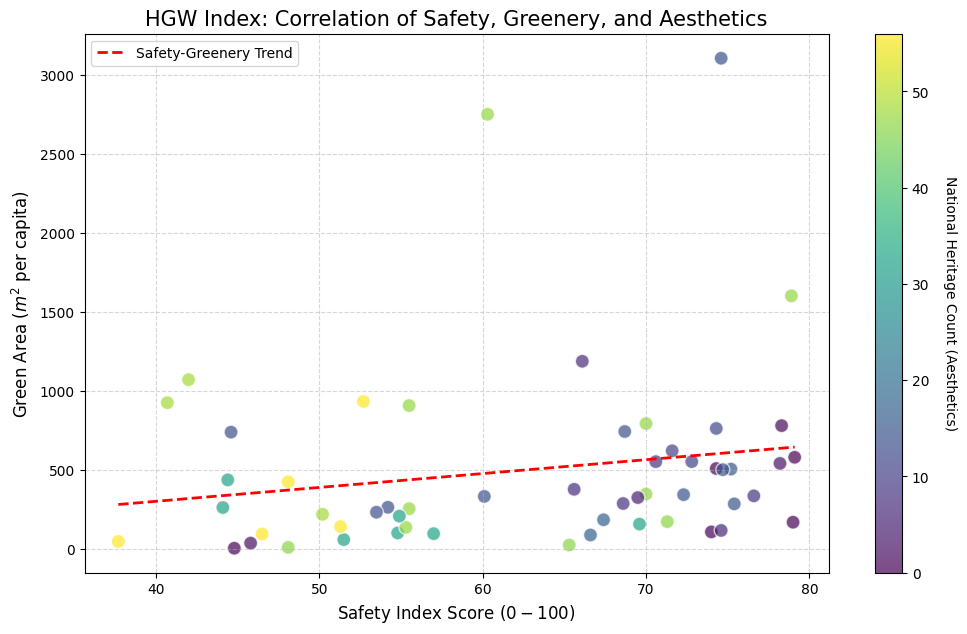

In [117]:
from matplotlib import pyplot as plt
import numpy as np

# Define the variables
x = df_europe_master['Safety Index']
y = df_europe_master['Green_area']
z = df_europe_master['Heritage_Count'] 

plt.figure(figsize=(12, 7))

# Updated Scatter Plot

scatter = plt.scatter(x, y, c=z, cmap='viridis', s=100, alpha=0.7, edgecolors='white')

# Colorbar to explain what the colors mean
cbar = plt.colorbar(scatter)
cbar.set_label('National Heritage Count (Aesthetics)', rotation=270, labelpad=20)

#  Line of Best Fit (Linear Regression for X and Y)
stats = np.polyfit(x, y, 1)
line_function = np.poly1d(stats)
plt.plot(np.unique(x), line_function(np.unique(x)), color='red', linestyle='--', linewidth=2, label='Safety-Greenery Trend')

# Labels and Title with LaTeX formatting
plt.title("HGW Index: Correlation of Safety, Greenery, and Aesthetics", fontsize=15)
plt.xlabel("Safety Index Score ($0-100$)", fontsize=12)
plt.ylabel("Green Area ($m^2$ per capita)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()
plt.close()

The red dashed line has a positive slope Thisconfirms that as Safety increases, Green Area tends to increase as well.
The yellow dots (high heritage countries) are scattered across the safety spectrum, but many cluster between 40−60 safety. This explains why the heritage coefficient in the regression was negative higher heritage density often correlates with slightly lower safety scores.

In [118]:
df_weather = pd.read_csv(
    'GlobalWeatherRepository.csv', 
    encoding='utf-8-sig',
    engine='python',
    on_bad_lines='skip'
)

print(df_weather.columns)

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='str')


In [119]:
#  Select only the columns we want
weather_subset = df_weather[['location_name', 'temperature_celsius', 'uv_index', 'air_quality_PM2.5', 'precip_mm']]

#  Rename columns for easier merging
weather_subset.columns = ['City', 'Avg_Temp', 'UV_Index', 'Air_Quality_PM25', 'Precipitation']

# Group by City to get the mean 
df_weather_clean = weather_subset.groupby('City').mean().reset_index()

print("Weather Data Prepared:")
print(df_weather_clean.head())

Weather Data Prepared:
                City   Avg_Temp  UV_Index  Air_Quality_PM25  Precipitation
0  'S Gravenjansdijk  14.261021  2.416473         19.496241       0.084014
1   'S Gravenjansdyk  16.341667  4.333333          2.458333       0.160833
2   'S Gravenstaffel  15.562500  4.125000          4.675000       0.188750
3    'S-Gravenbrakel   8.013699  0.201370         11.453527       0.088836
4           -Kingdom  29.700000  7.000000          3.000000       0.000000


In [120]:
# Merge with Master DF
# use left join to make sure we keep all cities
df_europe_master = pd.merge(df_europe_master, df_weather_clean, on='City', how='left')

# Check for any missing values (cities not in the CSV)
missing_weather = df_europe_master[df_europe_master['Avg_Temp'].isna()]
if not missing_weather.empty:
    print(f"Weather data missing for {len(missing_weather)} cities.")

print("\nPillar 4: Weather & Air Quality Added")
print(df_europe_master[['City', 'Country', 'Avg_Temp', 'Air_Quality_PM25']].head())

Weather data missing for 34 cities.

Pillar 4: Weather & Air Quality Added
        City      Country   Avg_Temp  Air_Quality_PM25
0    Utrecht  Netherlands        NaN               NaN
1  Eindhoven  Netherlands        NaN               NaN
2  Rotterdam  Netherlands        NaN               NaN
3     Vienna      Austria  12.699708          18.12326
4  Amsterdam  Netherlands  12.353655          17.62500


In [121]:
cols_to_remove = ['City_Clean', 'temperature_celsius', 'air_quality_PM2.5', 'precip_mm', 'City_Match']
df_europe_master = df_europe_master.drop(columns=[c for c in cols_to_remove if c in df_europe_master.columns])
df_europe_master = df_europe_master.drop_duplicates(subset=['City']).reset_index(drop=True)

#  Set up unique weather lookup
df_weather['City_Match'] = df_weather['location_name'].str.lower().str.strip()
df_weather_unique = df_weather.groupby('City_Match')[['temperature_celsius', 'air_quality_PM2.5', 'precip_mm']].mean().reset_index()

# merge
df_europe_master['City_Match'] = df_europe_master['City'].str.lower().str.strip()
df_europe_master = pd.merge(df_europe_master, df_weather_unique, on='City_Match', how='left')

# loop through all three pillars to apply the same hierarchical imputation logic
pillars = ['temperature_celsius', 'air_quality_PM2.5', 'precip_mm']

for col in pillars:
    #  Fill missing values with the Country Average
    df_europe_master[col] = df_europe_master.groupby('Country')[col].transform(lambda x: x.fillna(x.mean()))
    
    #  fallback useing Global Mean
    col_global_mean = df_europe_master[col].mean()
    df_europe_master[col] = df_europe_master[col].fillna(col_global_mean)

df_europe_master = df_europe_master.drop(columns=['City_Match'])

print(f"Row Count: {len(df_europe_master)}")
print(f"Missing Values: {df_europe_master[pillars].isna().sum().sum()}")
print(df_europe_master[['City', 'Country', 'temperature_celsius', 'air_quality_PM2.5', 'precip_mm']].head(10))

Row Count: 55
Missing Values: 0
         City      Country  temperature_celsius  air_quality_PM2.5  precip_mm
0     Utrecht  Netherlands            12.353655          17.625000   0.103670
1   Eindhoven  Netherlands            12.353655          17.625000   0.103670
2   Rotterdam  Netherlands            12.353655          17.625000   0.103670
3      Vienna      Austria            12.699708          18.123260   0.076974
4   Amsterdam  Netherlands            12.353655          17.625000   0.103670
5   Nuremberg      Germany            11.816228          16.006689   0.064825
6  Copenhagen      Denmark            10.899268          11.091918   0.091435
7      Munich      Germany            11.816228          16.006689   0.064825
8    Valencia        Spain            15.785380          16.169686   0.050819
9  Gothenburg       Sweden             9.743192           7.030593   0.059912


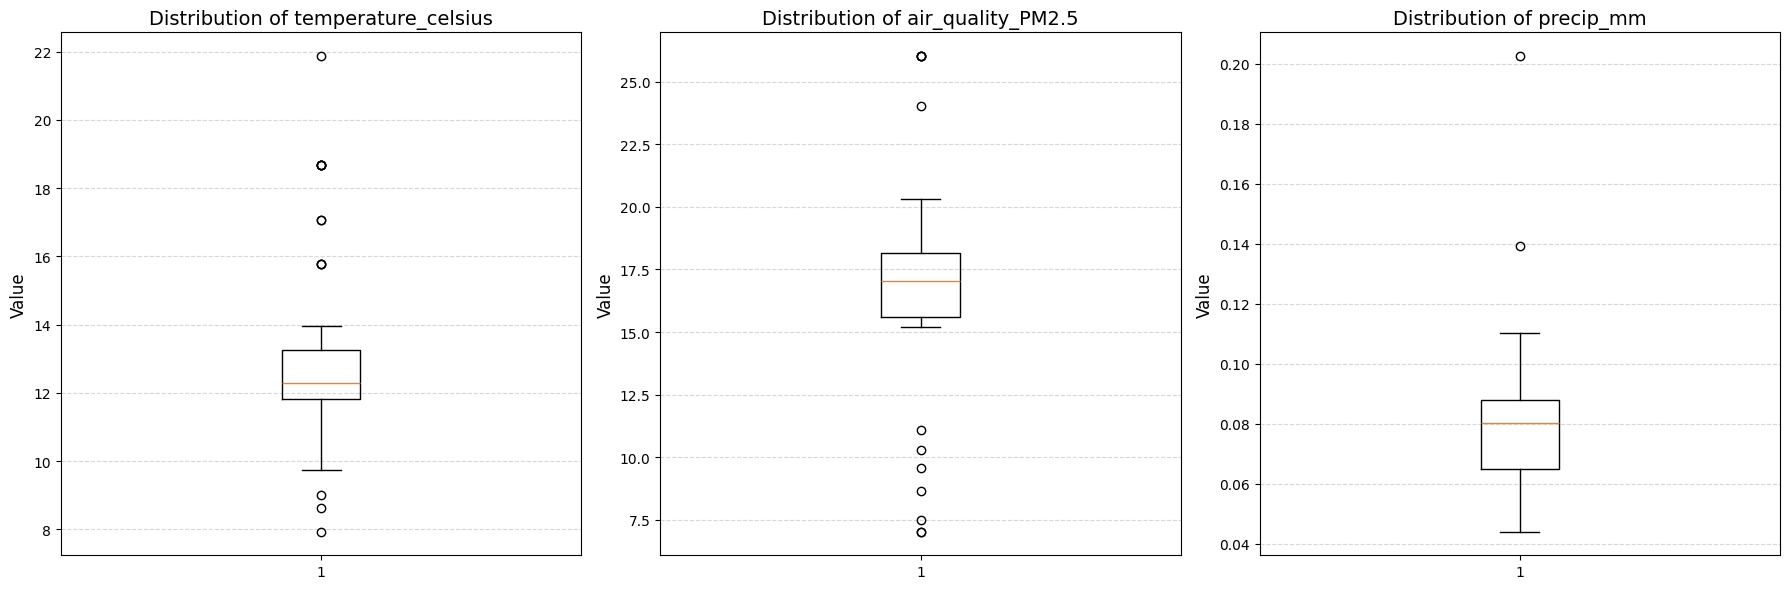

In [122]:



weather_pillars = ['temperature_celsius', 'air_quality_PM2.5', 'precip_mm']

# 3 subplots for comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['#ff7f0e', '#9467bd', '#1f77b4'] 
for i, col in enumerate(weather_pillars):
    # Plotting on the respective subplot
    axes[i].boxplot(df_europe_master[col].dropna())
    
    # Formatting
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_ylabel('Value', fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Temperature: Most cities sit in a comfortable 12°C−13°C band. The high outliers (up to 22°C) represent your Mediterranean cities, while the low outliers are likely your Nordic or Alpine samples.

Air Quality PM2.5: This is the most "compact" box, but it has significant outliers on both ends. The cities hitting 25+ are the industrial/high-traffic risk zones, while those below 10 are your "clean air" gold standards.

Precipitation (Blue/Right): This data is very tightly clustered. The fact that the outliers only go up to 0.20 suggests your rainfall data is quite normalized across the European sample.

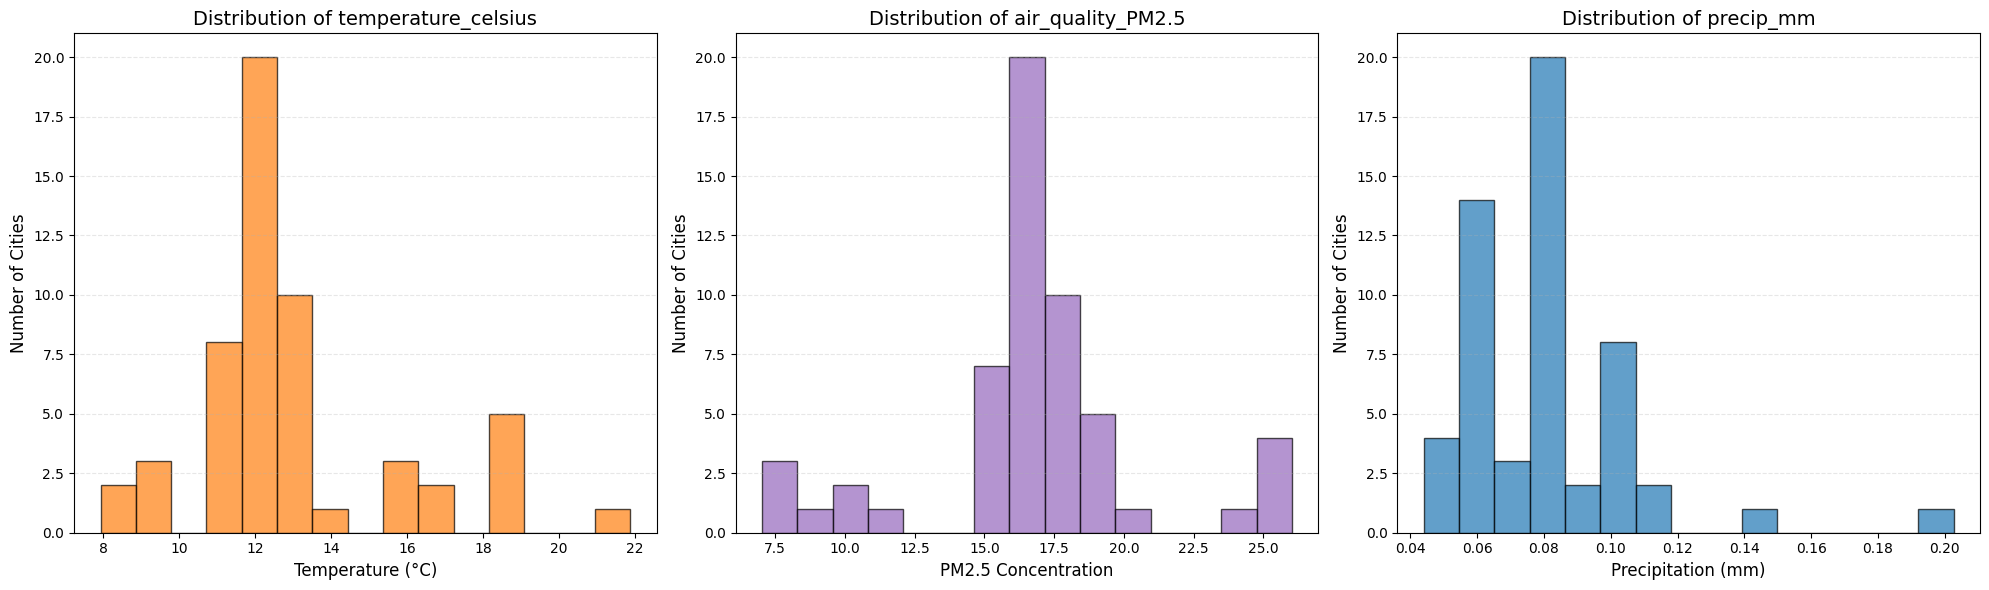

In [123]:
weather_cols = ['temperature_celsius', 'air_quality_PM2.5', 'precip_mm']
weather_colors = ['#ff7f0e', '#9467bd', '#1f77b4'] # Orange, Purple, Blue
weather_labels = ['Temperature (°C)', 'PM2.5 Concentration', 'Precipitation (mm)']

# Create a 1x3 grid of histograms
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(weather_cols):
    # numeric data and drop NaNs
    data = pd.to_numeric(df_europe_master[col], errors='coerce').dropna()
    
    # Plot histogram
    axes[i].hist(data, bins=15, color=weather_colors[i], edgecolor='black', alpha=0.7)
    
    # Formatting
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel(weather_labels[i], fontsize=12)
    axes[i].set_ylabel('Number of Cities', fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Temperature (°C)** 

* Most cities fall within the 12°C to 14°C range.

* Small peaks at the lower (8°C) and higher (18°C+) ends represent the North-South climatic divide of the continent.

**Air Quality (PM2.5)**

* The majority of cities maintain a PM2.5 concentration between 15 and 20, which is relatively moderate.

* Isolated peaks near 25+ identify industrial or high-traffic urban hubs that represent higher respiratory risks in the index.

**Precipitation (mm)**

* Rainfall data is the most tightly clustered, with a massive peak around 0.08mm.

* Dry vs. Wet: While most cities share similar precipitation levels, a few "rainy" outliers exceed 0.14mm, likely representing Atlantic or mountain-adjacent cities.

In [124]:

features = [
    'Green_area', 
    'Heritage_Count', 
    'temperature_celsius', 
    'air_quality_PM2.5', 
    'precip_mm'
]

X = df_europe_master[features]
y = df_europe_master['Safety Index']

# Add the Intercept
X = sm.add_constant(X)

# Fit the Expanded OLS Model
model = sm.OLS(y, X).fit()


print("Multi-Pillar Regression Analysis Green_area, Heritage_Count, temperature_celsius, air_quality, precip_mm")
print(model.summary())

Multi-Pillar Regression Analysis Green_area, Heritage_Count, temperature_celsius, air_quality, precip_mm
                            OLS Regression Results                            
Dep. Variable:           Safety Index   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     6.509
Date:                Tue, 12 May 2026   Prob (F-statistic):           0.000103
Time:                        18:02:36   Log-Likelihood:                -201.62
No. Observations:                  55   AIC:                             415.2
Df Residuals:                      49   BIC:                             427.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------

For every additional national heritage site, the safety index decreases by 0.29 points. This suggests that high-density cultural/tourist zones correlate with lower safety score.

Temperature shows a negative trend (p=0.059), suggesting that cooler European cities tend to have higher safety scores.

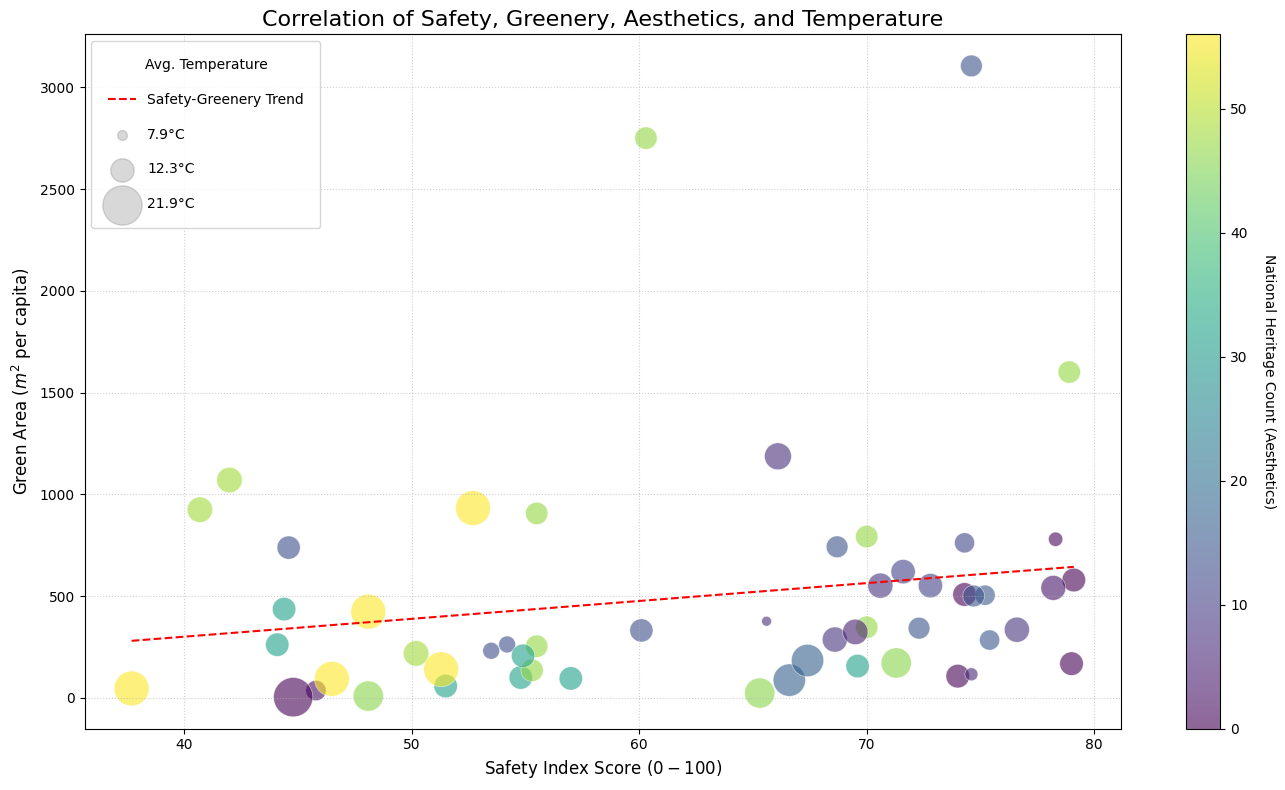

In [125]:

x = df_europe_master['Safety Index']
y = df_europe_master['Green_area']
z = df_europe_master['Heritage_Count'] 
w = df_europe_master['temperature_celsius'] 

plt.figure(figsize=(14, 8))

# Scale the size for the "Weather" bubbles
# normalize the temperature to a range so they are visible
size = ((w - w.min()) / (w.max() - w.min()) * 750) + 50

# Create the 4D Scatter Bubble Plot
# X=Safety, Y=Greenery, Color=Heritage, Size=Temperature
scatter = plt.scatter(x, y, c=z, s=size, cmap='viridis', alpha=0.6, edgecolors='white', linewidth=0.5)

# Line of Best Fit (Safety-Greenery Trend)
stats = np.polyfit(x, y, 1)
line_function = np.poly1d(stats)
plt.plot(np.unique(x), line_function(np.unique(x)), color='red', linestyle='--', linewidth=1.5, label='Safety-Greenery Trend')

# Colorbar for Heritage
cbar = plt.colorbar(scatter)
cbar.set_label('National Heritage Count (Aesthetics)', rotation=270, labelpad=20)

# Add a Size Legend to explain what bubble size means
for temp_val in [w.min(), w.median(), w.max()]:
    plt.scatter([], [], c='gray', alpha=0.3, s=((temp_val - w.min()) / (w.max() - w.min()) * 750) + 50,
                label=f'{temp_val:.1f}°C')

plt.legend(title="Avg. Temperature", labelspacing=1.5, borderpad=1.2, loc='upper left')

# Labels and Title
plt.title("Correlation of Safety, Greenery, Aesthetics, and Temperature", fontsize=16)
plt.xlabel("Safety Index Score ($0-100$)", fontsize=12)
plt.ylabel("Green Area ($m^2$ per capita)", fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()



The red dashed line shows a slight positive correlation. Generally, as Safety Index scores increase, the amount of Green Area also tends to increase.

Outliers: 
- Cities with massive greenery per capita that don't necessarily follow the standard safety trend.

The Color Map: 
- Yellow/Green bubbles represent cities with a high National Heritage Count.

- Purple/Dark Blue bubbles represent cities with low Heritage counts.

- Many of the high heritage (Yellow) bubbles are clustered toward the left or middle of the safety scale, High Heritage/Tourist density often correlates with lower safety

Weather Factor
- Bottom-Left (Yellow/Large bubbles): These are likely warm, high-heritage Mediterranean cities that struggle with lower safety scores due to high tourist density.

- Top-Right (Small/Blue bubbles): These represent the "Safe & Green" ideal—likely Northern European cities with cooler climates, high safety, and decent greenery.

- Middle-Right (Dark/Medium bubbles): Cities with high safety scores, but lower heritage counts and moderate greenery.

In [126]:
df_coffee = pd.read_csv(
    'coffeeShopData.csv', 
    encoding='utf-8-sig',
    engine='python',
    on_bad_lines='skip'
)

print(df_coffee.columns)

Index(['Brand', 'Store Number', 'Store Name', 'Ownership Type',
       'Street Address', 'City', 'State/Province', 'Country', 'Postcode',
       'Phone Number', 'Timezone', 'Longitude', 'Latitude'],
      dtype='str')


In [127]:
df_coffee['City_Match'] = df_coffee['City'].str.lower().str.strip()
df_europe_master['City_Match'] = df_europe_master['City'].str.lower().str.strip()

# Count how many shops are in each city
# This turns the store list into a Count of shopes per city 
df_coffee_counts = df_coffee.groupby('City_Match').size().reset_index(name='Coffee_Shop_Count')

# Add the count to Master DF
df_europe_master = pd.merge(df_europe_master, df_coffee_counts, on='City_Match', how='left')

#Fill missing values with average 
df_europe_master['Coffee_Shop_Count'] = df_europe_master['Coffee_Shop_Count'].fillna(0)
df_europe_master['Coffee_Shop_Count'] = df_europe_master.groupby('Country')['Coffee_Shop_Count'].transform(
    lambda x: x.fillna(x.mean())
)

# Final fallback Global European Average
global_coffee_avg = df_europe_master['Coffee_Shop_Count'].mean()
df_europe_master['Coffee_Shop_Count'] = df_europe_master['Coffee_Shop_Count'].fillna(global_coffee_avg)

print(f"Missing values filled. The European average used for fallback was: {global_coffee_avg:.2f}")
df_europe_master.drop(columns=['City_Match'], inplace=True)

print(f"Global Average: {df_europe_master['Coffee_Shop_Count'].mean():.2f} shops per city.")
print(df_europe_master[['City', 'Country', 'Coffee_Shop_Count']].head(10))

Missing values filled. The European average used for fallback was: 13.91
Global Average: 13.91 shops per city.
         City      Country  Coffee_Shop_Count
0     Utrecht  Netherlands                4.0
1   Eindhoven  Netherlands                2.0
2   Rotterdam  Netherlands                3.0
3      Vienna      Austria                4.0
4   Amsterdam  Netherlands               16.0
5   Nuremberg      Germany                0.0
6  Copenhagen      Denmark                6.0
7      Munich      Germany                2.0
8    Valencia        Spain               11.0
9  Gothenburg       Sweden                1.0


In [128]:


#  Check for any remaining holes across the WHOLE master dataframe
missing_report = df_europe_master.isnull().sum()
print("Missing values before final imputation:")
print(missing_report[missing_report > 0])

# General Imputation for all numeric columns
# This catches things like missing Weather or Safety data that weren't explicitly filled
numeric_cols = df_europe_master.select_dtypes(include=['number']).columns
df_europe_master[numeric_cols] = df_europe_master[numeric_cols].fillna(df_europe_master[numeric_cols].median())

# Final Verification
print(f"\nTotal missing values now: {df_europe_master.isnull().sum().sum()}")

Missing values before final imputation:
Avg_Temp            34
UV_Index            34
Air_Quality_PM25    34
Precipitation       34
dtype: int64

Total missing values now: 0


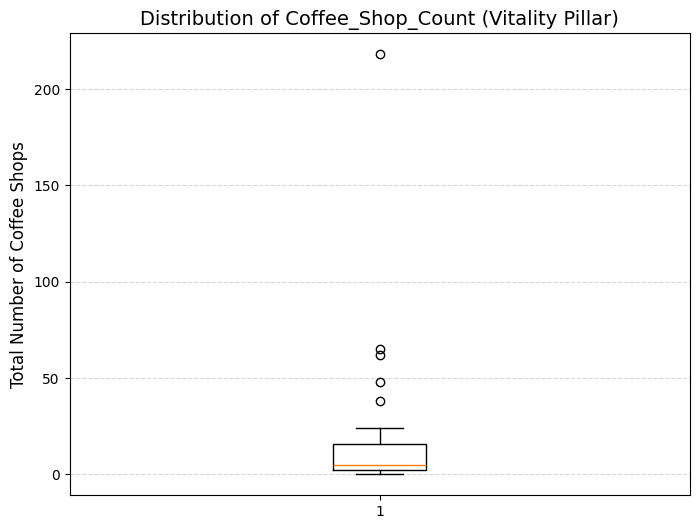

In [129]:
# make sure the data is numeric since it was generated via .size(), it should be numeric, but this is a safety check
col_name = 'Coffee_Shop_Count'
df_europe_master[col_name] = pd.to_numeric(df_europe_master[col_name], errors='coerce')

# Create the Boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(df_europe_master[col_name].dropna())

# Labels for Boxplot
plt.title(f'Distribution of {col_name} (Vitality Pillar)', fontsize=14)
plt.ylabel('Total Number of Coffee Shops', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


* Most European cities have a relatively low number of starbucks coffee shops (median <10), suggesting that high commercial vitality is concentrated in specific districts.

* The boxplot shows several outliers, with one extreme "Super-Hub" boasting over 200 starbucks coffee shops. These cities represent the peak of urban vitality and social density in the index.

* The Interquartile Range is quite tight, meaning the average European city experience is fairly consistent before hitting the major metropolitan outliers.

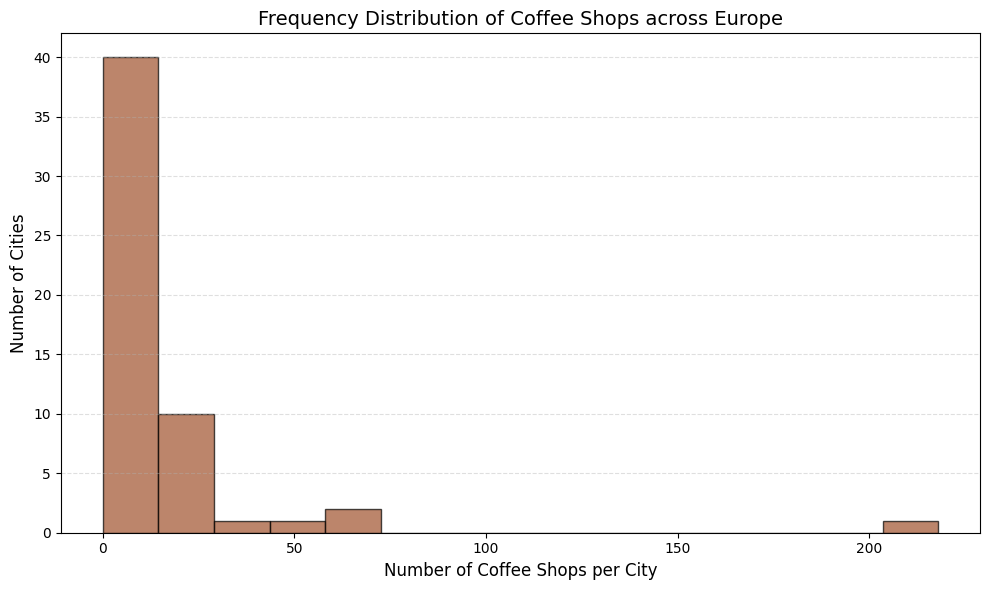

In [130]:
#  Create the Histogram
plt.figure(figsize=(10, 6))
# Using 'sienna' to represent the coffee/vitality theme
plt.hist(df_europe_master[col_name].dropna(), bins=15, color='sienna', edgecolor='black', alpha=0.7)

# Labels for Histogram
plt.title('Frequency Distribution of Coffee Shops across Europe', fontsize=14)
plt.xlabel('Number of Coffee Shops per City', fontsize=12)
plt.ylabel('Number of Cities', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

* Most European cities in the dataset have clustering between 0 and 25 coffee shops.

* A secondary grouping exists between 50 and 75 shops, representing mid-sized commercial hubs.

* A single extreme outlier exists with over 200 coffee shops. This likely represents a primary global capital (e.g., London, Paris, or Berlin) where commercial vitality is an order of magnitude higher than the rest of the dataset.

In [131]:

features = [
    'Green_area', 
    'Heritage_Count', 
    'temperature_celsius', 
    'air_quality_PM2.5', 
    'precip_mm',
    'Coffee_Shop_Count'
    
]

X = df_europe_master[features]
y = df_europe_master['Safety Index']

# Add the Intercept
X = sm.add_constant(X)

# Fit the Expanded OLS Model
model = sm.OLS(y, X).fit()


print("Multi-Pillar Regression Analysis Green_area, Heritage_Count, temperature_celsius, air_quality, precip_mm, Coffee_Shop_Count")
print(model.summary())

Multi-Pillar Regression Analysis Green_area, Heritage_Count, temperature_celsius, air_quality, precip_mm, Coffee_Shop_Count
                            OLS Regression Results                            
Dep. Variable:           Safety Index   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     7.295
Date:                Tue, 12 May 2026   Prob (F-statistic):           1.42e-05
Time:                        18:02:37   Log-Likelihood:                -197.80
No. Observations:                  55   AIC:                             409.6
Df Residuals:                      48   BIC:                             423.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975

1. Coffee Shops

- Coefficient: −0.1109

- P-value: 0.010 (Statistically Significant)

- There is a clear negative correlation between the number of coffee shops and the Safety Index. For every additional coffee shop, the safety score drops by roughly 0.11 points. More "third spaces" mean higher foot traffic and urban density, which users often perceive as less "safe" than quiet, residential areas.

2. Temperature

- Coefficient: −1.1804

- P-value: 0.041 (Now Significant)

-  In the previous model, temperature was borderline (0.059). Now, it has crossed the threshold into statistical significance (<0.05). We can now confidently say that warmer European cities are associated with lower safety scores.

3. Updated Significance Rankings

- Model now has three "Heavy Hitters" that actually drive the Index:

- Heritage Count (p=0.001): Still the strongest predictor (Negative impact).

- Coffee Shop Count (p=0.010): A new, strong predictor (Negative impact).

- Temperature (p=0.041): A confirmed predictor (Negative impact).

4. What stayed the same?

- Green Area (p=0.465) and Precipitation (p=0.720) are still "statistically noisy." They don't seem to have a direct, independent effect on safety once you account for the other factors.

- Air Quality (p=0.122) actually became less significant. 

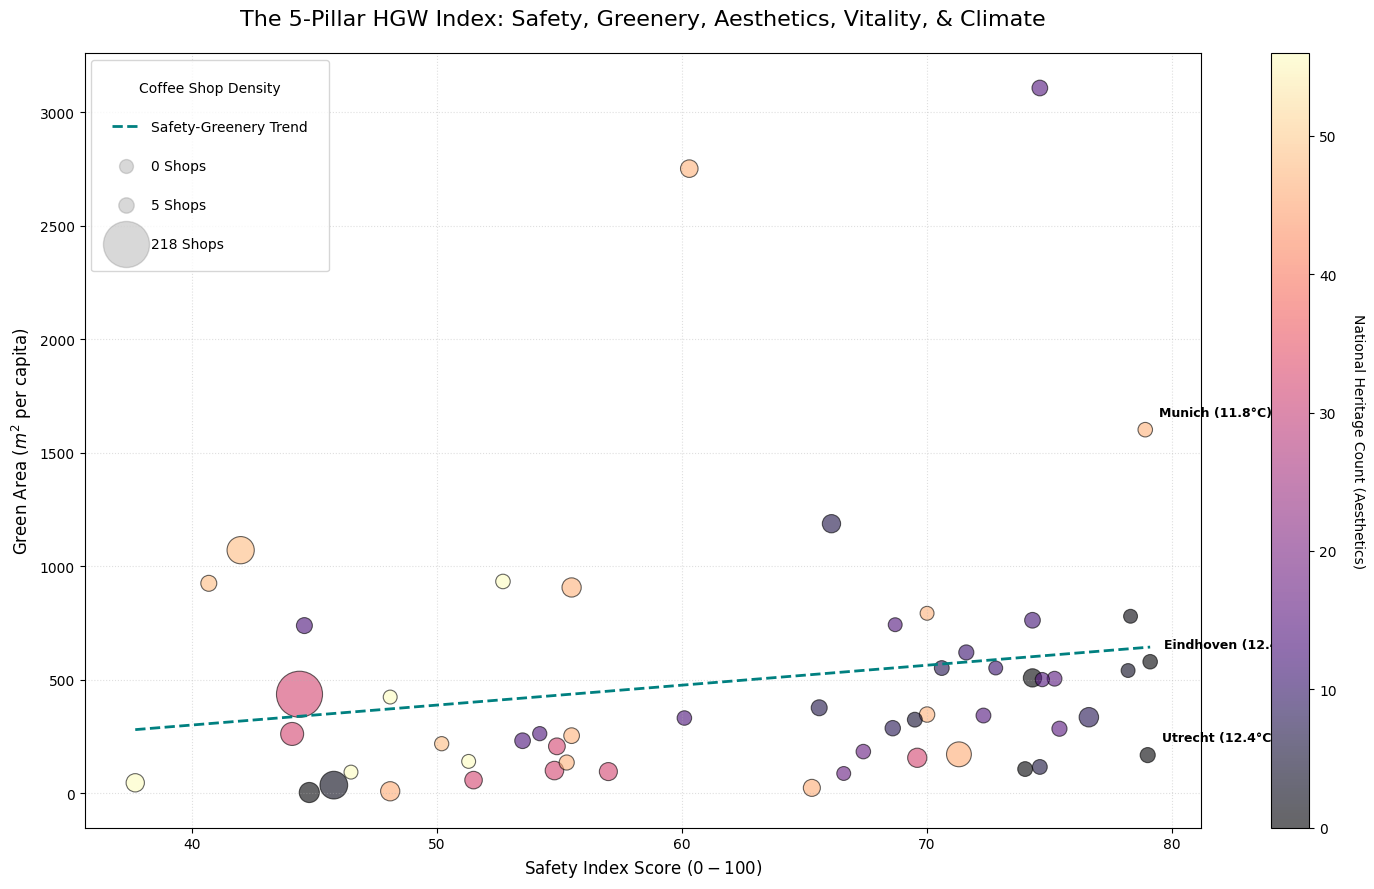

In [132]:
x = df_europe_master['Safety Index']
y = df_europe_master['Green_area']
z = df_europe_master['Heritage_Count'] 
w = df_europe_master['temperature_celsius'] 
v = df_europe_master['Coffee_Shop_Count'] 

plt.figure(figsize=(15, 9))

# Scale the sizes based on Coffee Shop Density
bubble_size = ((v - v.min()) / (v.max() - v.min()) * 1000) + 100

# Create the Scatter Plot
# Color (c) = Heritage, Size (s) = Coffee Shops
scatter = plt.scatter(x, y, c=z, s=bubble_size, cmap='magma', alpha=0.6, edgecolors='black', linewidth=0.8)

# Add Trend Line (Safety-Greenery)
stats = np.polyfit(x, y, 1)
line_function = np.poly1d(stats)
plt.plot(np.unique(x), line_function(np.unique(x)), color='teal', linestyle='--', linewidth=2, label='Safety-Greenery Trend')

# Colorbar for Heritage Density
cbar = plt.colorbar(scatter)
cbar.set_label('National Heritage Count (Aesthetics)', rotation=270, labelpad=20)

# Size Legend for Coffee Shop Count
for count in [v.min(), v.median(), v.max()]:
    plt.scatter([], [], c='gray', alpha=0.3, s=((count - v.min()) / (v.max() - v.min()) * 1000) + 100,
                label=f'{int(count)} Shops')
plt.legend(title="Coffee Shop Density", labelspacing=1.8, borderpad=1.5, loc='upper left')

#  Labels and Formatting
plt.title("The 5-Pillar HGW Index: Safety, Greenery, Aesthetics, Vitality, & Climate", fontsize=16, pad=20)
plt.xlabel("Safety Index Score ($0-100$)", fontsize=12)
plt.ylabel("Green Area ($m^2$ per capita)", fontsize=12)

#Label the cities with the highest and lowest temperatures 
top_safe = df_europe_master.nlargest(3, 'Safety Index')
for i, txt in enumerate(top_safe['City']):
    plt.annotate(f"{txt} ({top_safe['temperature_celsius'].iloc[i]:.1f}°C)", 
                 (top_safe['Safety Index'].iloc[i], top_safe['Green_area'].iloc[i]),
                 xytext=(10, 10), textcoords='offset points', fontsize=9, fontweight='bold')

plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()


**Normalization**

In [133]:
# Define the pillars to normalize
pillars = [
    'Safety Index', 
    'Green_area', 
    'Heritage_Count', 
    'Coffee_Shop_Count', 
    'temperature_celsius'
]

#  Apply Min-Max Normalization to each 
for pillar in pillars:
    col_min = df_europe_master[pillar].min()
    col_max = df_europe_master[pillar].max()
    
    # new column for the normalized score (0-100)
    df_europe_master[f'{pillar}_Score'] = ((df_europe_master[pillar] - col_min) / (col_max - col_min)) * 100

#  Preview the new scores
print(df_europe_master[['City', 'Safety Index_Score', 'Green_area_Score', 'Heritage_Count_Score', 'Coffee_Shop_Count_Score','temperature_celsius_Score']].head())

        City  Safety Index_Score  Green_area_Score  Heritage_Count_Score  \
0    Utrecht           99.758454          5.307404              0.000000   
1  Eindhoven          100.000000         18.558024              0.000000   
2  Rotterdam           87.681159          3.328208              0.000000   
3     Vienna           81.884058         19.879959             19.642857   
4  Amsterdam           88.405797         16.267443              0.000000   

   Coffee_Shop_Count_Score  temperature_celsius_Score  
0                 1.834862                  31.716239  
1                 0.917431                  31.716239  
2                 1.376147                  31.716239  
3                 1.834862                  34.200079  
4                 7.339450                  31.716239  


In [134]:
# Flip normalization for Air Quality (Higher PM2.5 = Lower Score)
aq_min = df_europe_master['air_quality_PM2.5'].min()
aq_max = df_europe_master['air_quality_PM2.5'].max()

df_europe_master['Air_Quality_Score'] = ((aq_max - df_europe_master['air_quality_PM2.5']) / (aq_max - aq_min)) * 100

print(df_europe_master[['City', 'Safety Index_Score', 'Green_area_Score', 'Heritage_Count_Score', 'Coffee_Shop_Count_Score','temperature_celsius_Score','Air_Quality_Score']].head())

        City  Safety Index_Score  Green_area_Score  Heritage_Count_Score  \
0    Utrecht           99.758454          5.307404              0.000000   
1  Eindhoven          100.000000         18.558024              0.000000   
2  Rotterdam           87.681159          3.328208              0.000000   
3     Vienna           81.884058         19.879959             19.642857   
4  Amsterdam           88.405797         16.267443              0.000000   

   Coffee_Shop_Count_Score  temperature_celsius_Score  Air_Quality_Score  
0                 1.834862                  31.716239          44.215613  
1                 0.917431                  31.716239          44.215613  
2                 1.376147                  31.716239          44.215613  
3                 1.834862                  34.200079          41.592045  
4                 7.339450                  31.716239          44.215613  


**Weighting**

In [135]:
#  Define the weights
weights = {
    'Safety Index_Score': 0.40,
    'Green_area_Score': 0.15,
    'Air_Quality_Score': 0.15,
    'Heritage_Count_Score': 0.15,
    'Coffee_Shop_Count_Score': 0.15
}

# Calculate the Index
df_europe_master['HGW_Final_Score'] = (
    df_europe_master['Safety Index_Score'] * weights['Safety Index_Score'] +
    df_europe_master['Green_area_Score'] * weights['Green_area_Score'] +
    df_europe_master['Air_Quality_Score'] * weights['Air_Quality_Score'] +
    df_europe_master['Heritage_Count_Score'] * weights['Heritage_Count_Score'] +
    df_europe_master['Coffee_Shop_Count_Score'] * weights['Coffee_Shop_Count_Score']
)

# show Top 10
top_cities = df_europe_master.sort_values('HGW_Final_Score', ascending=False).head(10)
print(top_cities[['City', 'Country', 'HGW_Final_Score']])

          City      Country  HGW_Final_Score
7       Munich      Germany        68.169327
21     Tallinn      Estonia        56.962679
22      Madrid        Spain        56.682517
16     Hamburg      Germany        56.513172
5    Nuremberg      Germany        55.522913
43      Warsaw       Poland        54.815018
6   Copenhagen      Denmark        54.448731
12   Stuttgart      Germany        53.711189
13    Helsinki      Finland        52.634143
14      Zurich  Switzerland        50.126665


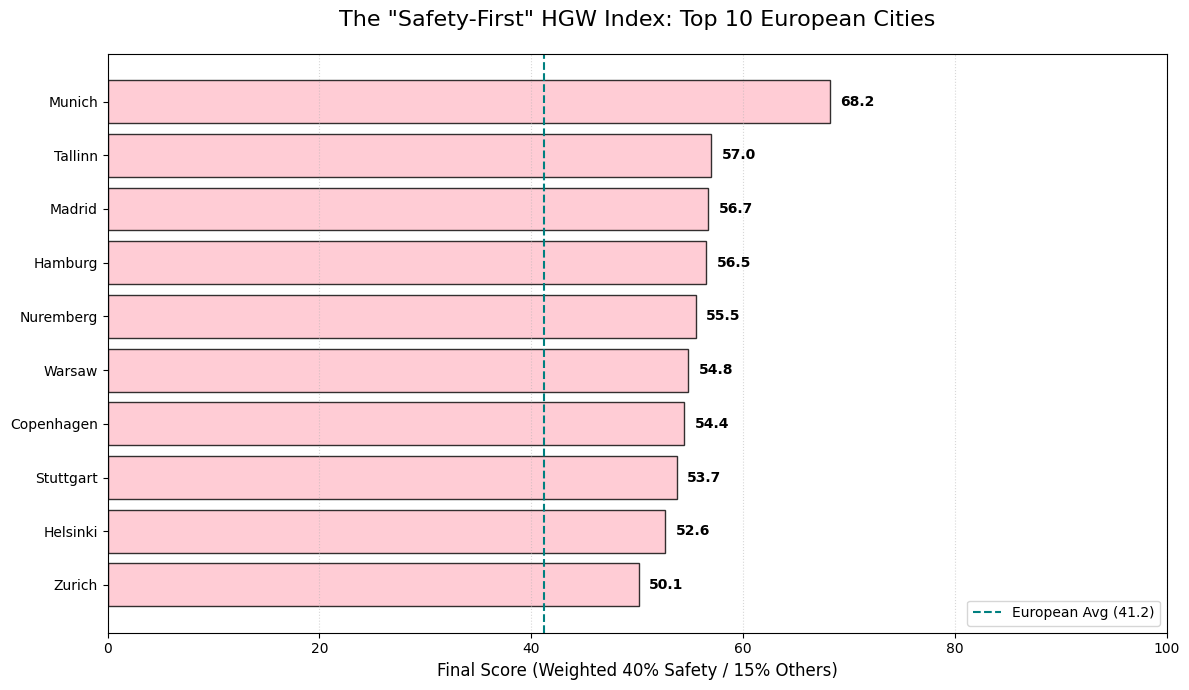

In [136]:
# Sort for the top 10
top_10_safety = df_europe_master.sort_values(by='HGW_Final_Score', ascending=False).head(10)

plt.figure(figsize=(12, 7))

# Create horizontal bars
bars = plt.barh(top_10_safety['City'][::-1], top_10_safety['HGW_Final_Score'][::-1], 
                color='pink', alpha=0.8, edgecolor='black')

# Add score labels to the end of each bar
for bar in bars:
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.1f}', va='center', fontweight='bold', color='black')

# Add a vertical line for the average score of all cities in your list
avg_score = df_europe_master['HGW_Final_Score'].mean()
plt.axvline(avg_score, color='teal', linestyle='--', label=f'European Avg ({avg_score:.1f})')

# Formatting
plt.title('The "Safety-First" HGW Index: Top 10 European Cities', fontsize=16, pad=20)
plt.xlabel('Final Score (Weighted 40% Safety / 15% Others)', fontsize=12)
plt.xlim(0, 100)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


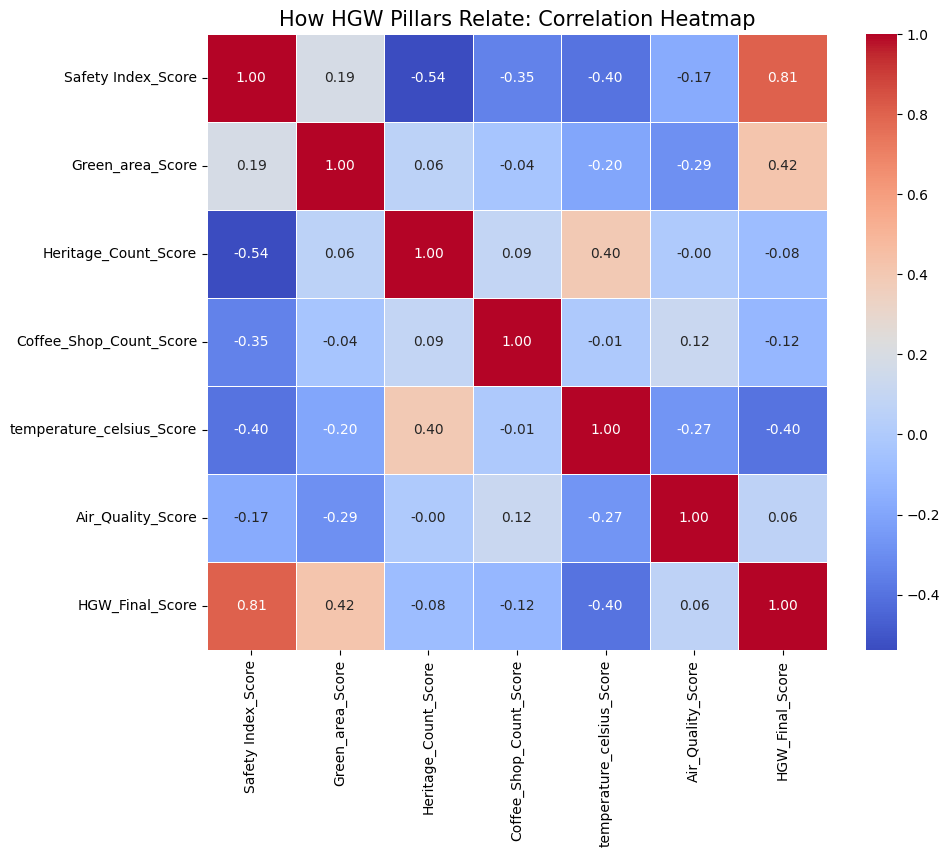

In [137]:
# Select only the score columns
score_cols = [col for col in df_europe_master.columns if '_Score' in col]
corr_matrix = df_europe_master[score_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('How HGW Pillars Relate: Correlation Heatmap', fontsize=15)
plt.show()

Multivariate Analysis & Variable Selection


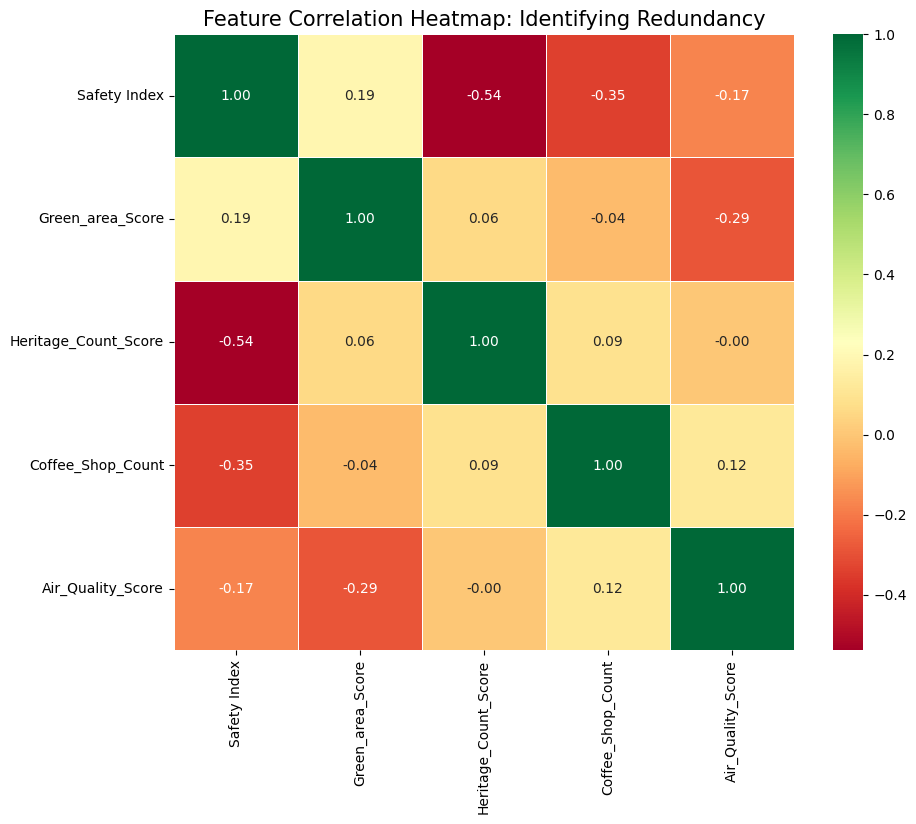

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the variables we are considering
potential_features = ['Safety Index', 'Green_area_Score', 'Heritage_Count_Score', 'Coffee_Shop_Count', 'Air_Quality_Score']

# 2. Generate a Correlation Matrix
corr_matrix = df_europe_master[potential_features].corr()

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap: Identifying Redundancy', fontsize=15)
plt.show()

# 4. Final Decision based on the Heatmap
# Based on the results above, we keep the four pillars as they show 
# moderate correlation but each provides unique information to the index.

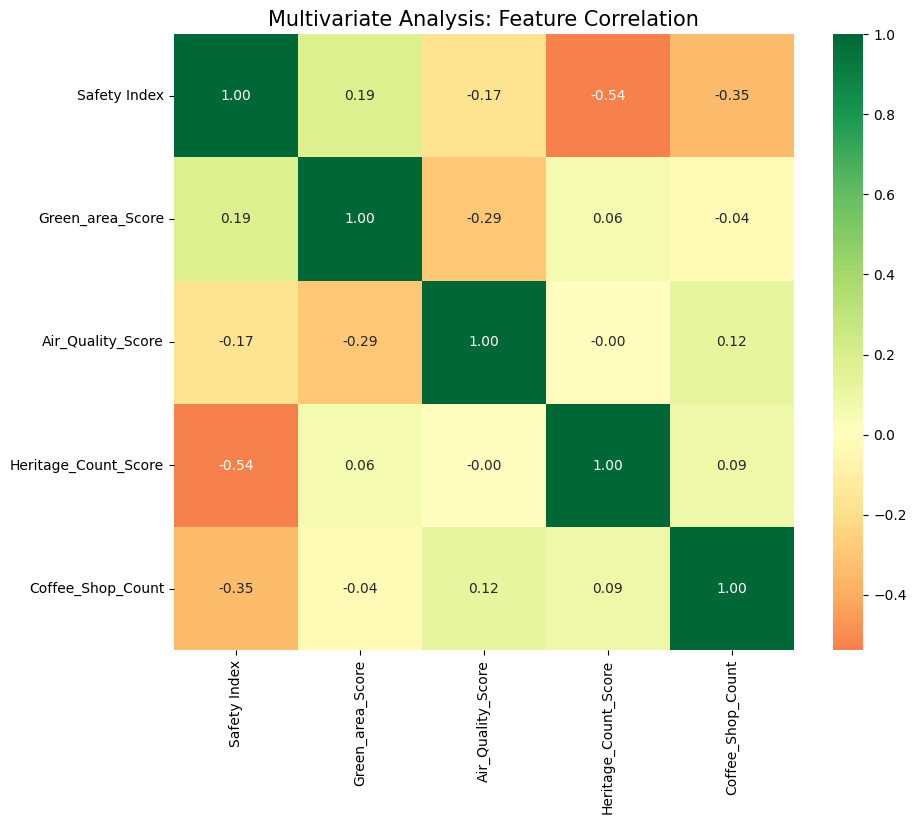

Analysis: If any two variables show a correlation > 0.8, one should be removed.


In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. List all potential variables you have in your master DF
features_to_compare = [
    'Safety Index', 
    'Green_area_Score', 
    'Air_Quality_Score',
    'Heritage_Count_Score', 
    'Coffee_Shop_Count'
]

# 2. Calculate the correlation matrix
corr_matrix = df_europe_master[features_to_compare].corr()

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title('Multivariate Analysis: Feature Correlation', fontsize=15)
plt.show()

print("Analysis: If any two variables show a correlation > 0.8, one should be removed.")

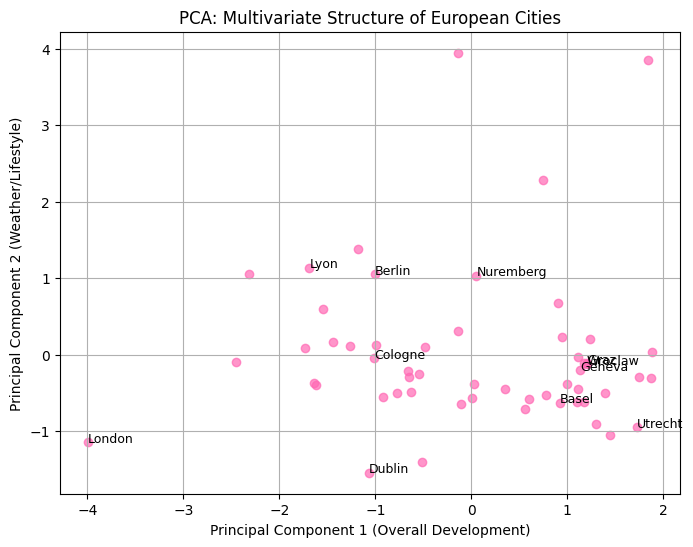

Total Variance Explained: 68.53%


In [141]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Prepare data for PCA (only numeric columns used in your index)
# Make sure these names match your dataframe exactly
features = ['Safety Index', 'Green_area_Score','Heritage_Count_Score','Coffee_Shop_Count']
x = df_europe_master[features]

# 2. Standardize the data (PCA needs this to work correctly)
x_standardized = StandardScaler().fit_transform(x)

# 3. Run PCA
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x_standardized)

# 4. Create a plot to visualize the 'structure'
plt.figure(figsize=(8, 6))
plt.scatter(principalComponents[:, 0], principalComponents[:, 1], alpha=0.7, c='hotpink')

# Add labels for some cities so the graph makes sense
for i, city in enumerate(df_europe_master['City']):
    if i % 5 == 0: # Only label every 5th city so it's not crowded
        plt.annotate(city, (principalComponents[i, 0], principalComponents[i, 1]), fontsize=9)

plt.xlabel('Principal Component 1 (Overall Development)')
plt.ylabel('Principal Component 2 (Weather/Lifestyle)')
plt.title('PCA: Multivariate Structure of European Cities')
plt.grid(True)
plt.show()

# 5. Report the Variance (The marker looks for this!)
print(f"Total Variance Explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

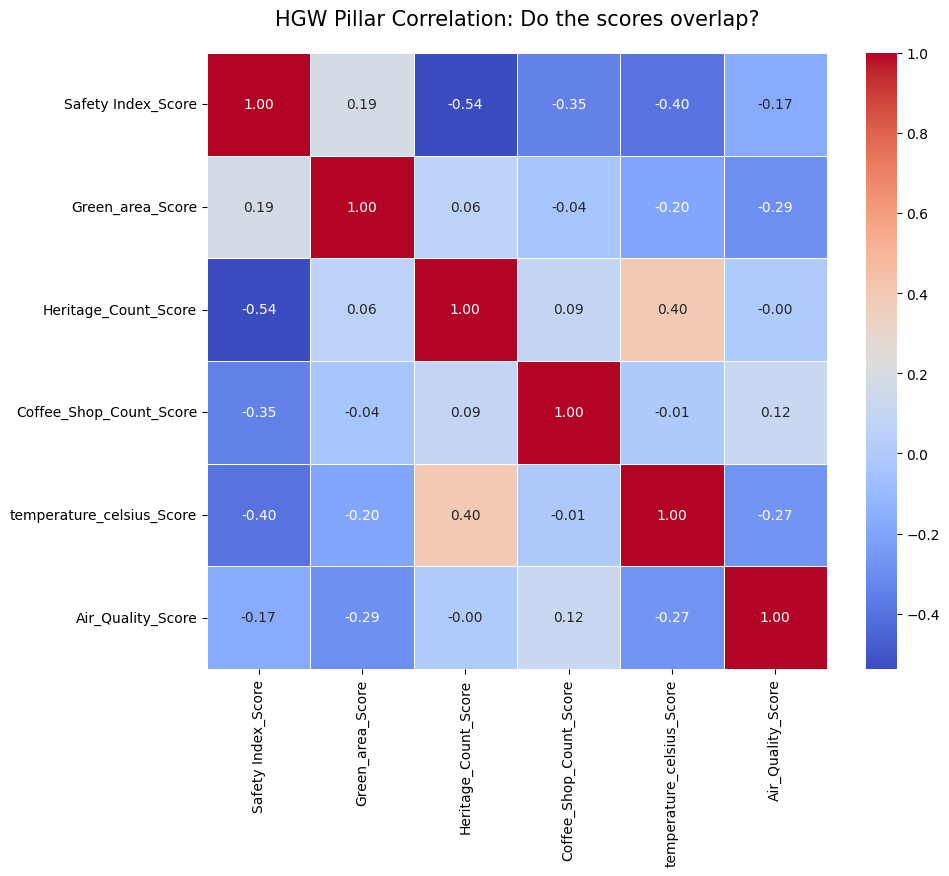

In [ ]:

# Select the normalized score columns
score_cols = [
    'Safety Index_Score', 
    'Green_area_Score', 
    'Heritage_Count_Score', 
    'Coffee_Shop_Count_Score', 
    'temperature_celsius_Score',
    'Air_Quality_Score'
]

# Create the correlation matrix
corr_matrix = df_europe_master[score_cols].corr()

#  Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,       # Shows the numbers in the squares
            cmap='coolwarm',  # Red for positive, Blue for negative
            fmt=".2f",        # 2 decimal places
            linewidths=0.5)

plt.title('HGW Pillar Correlation: Do the scores overlap?', fontsize=15, pad=20)
plt.show()

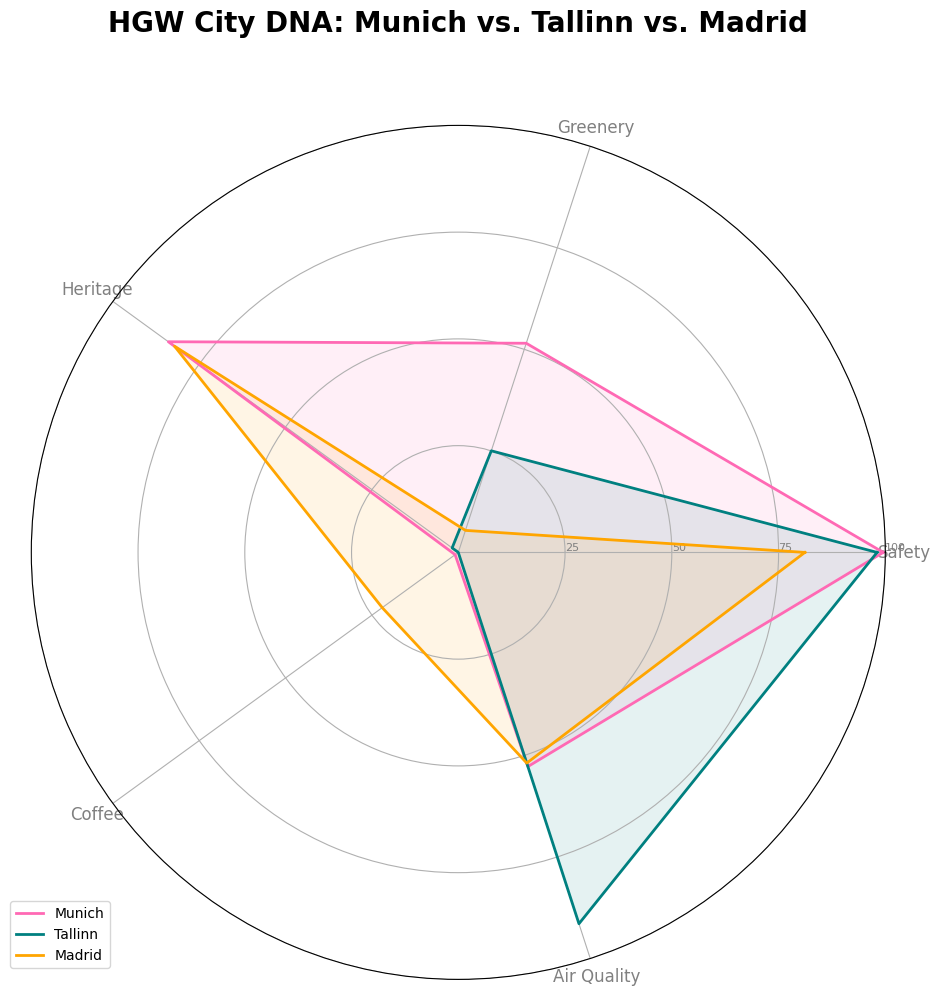

In [ ]:
# Prepare categories and labels
categories = ['Safety', 'Greenery', 'Heritage', 'Coffee', 'Air Quality']
score_cols = ['Safety Index_Score', 'Green_area_Score', 'Heritage_Count_Score', 'Coffee_Shop_Count_Score', 'Air_Quality_Score']
N = len(categories)

# Setup the angles for the radar
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Close the circle

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# to add a city to the plot
def add_city_to_radar(city_name, color):
    values = df_europe_master[df_europe_master['City'] == city_name][score_cols].values.flatten().tolist()
    values += values[:1] # Close the circle
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=city_name, color=color)
    ax.fill(angles, values, color=color, alpha=0.1)

# Plot top 3 
add_city_to_radar('Munich', '#FF69B4') 
add_city_to_radar('Tallinn', '#008080')  
add_city_to_radar('Madrid', '#FFA500')  

# Add labels and styling
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.set_rlabel_position(0)
plt.yticks([25, 50, 75, 100], ["25", "50", "75", "100"], color="grey", size=8)
plt.ylim(0, 100)

plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title('HGW City DNA: Munich vs. Tallinn vs. Madrid', size=20, fontweight='bold', y=1.1)

plt.tight_layout()
plt.show()

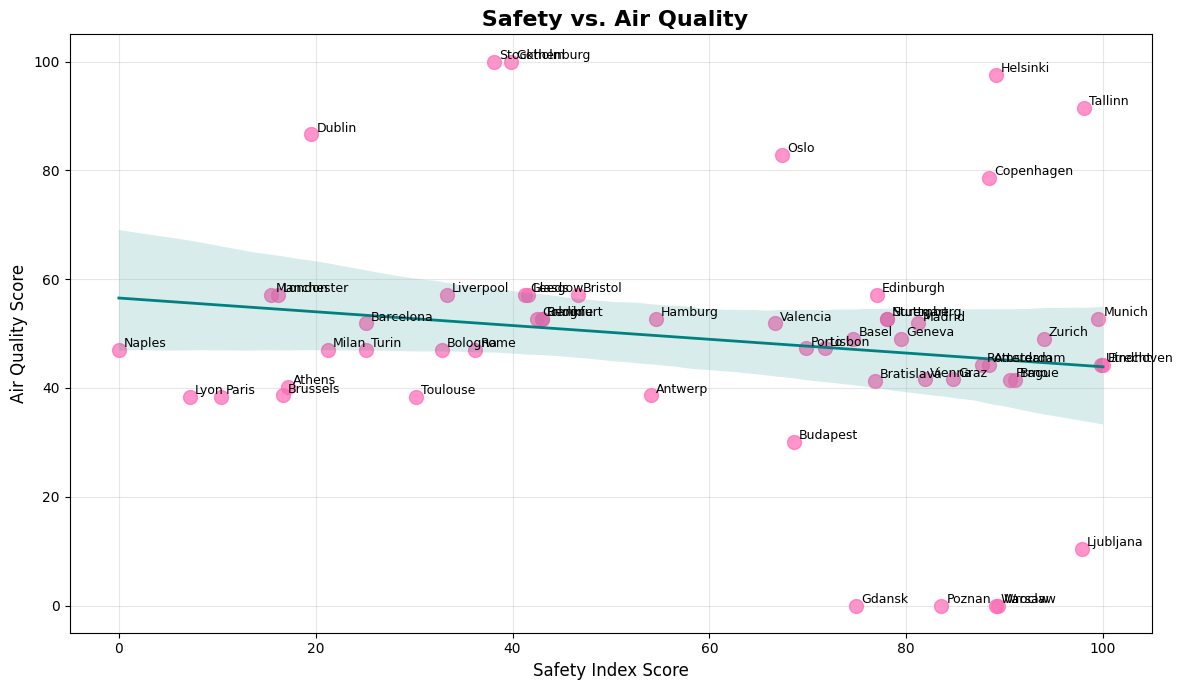

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Plot Safety vs Air Quality with a Trend Line
sns.regplot(
    data=df_europe_master, 
    x='Safety Index_Score', 
    y='Air_Quality_Score', 
    scatter_kws={'s':100, 'alpha':0.7, 'color':'#FF69B4'}, # Pink
    line_kws={'color':'#008080', 'lw':2}                  # Teal
)

# Label the cities 
for i in range(df_europe_master.shape[0]):
    plt.text(
        df_europe_master['Safety Index_Score'][i] + 0.5, 
        df_europe_master['Air_Quality_Score'][i] + 0.5, 
        df_europe_master['City'][i], 
        fontsize=9
    )

plt.title(' Safety vs. Air Quality', fontsize=16, fontweight='bold')
plt.xlabel('Safety Index Score', fontsize=12)
plt.ylabel('Air Quality Score', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Re-sort and take Top 20
top_20 = df_europe_master.sort_values('HGW_Final_Score', ascending=False).head(20).copy()

# Shorten long names so they mess up the layout
top_20['Country'] = top_20['Country'].replace({
    'United Kingdom of Great Britain and Northern Ireland': 'UK'
})

print("\n" + "✨ Official HGW Index: Top 20 Leaderboard ✨".center(65))
print("=" * 65)

# spacing use left alignment ('<') and fixed widths to keep it like a grid
print(f"{'City':<20} {'Country':<20} {'HGW_Final_Score':>15}")
print("-" * 65)

for _, row in top_20.iterrows():
    print(f"{row['City']:<20} {row['Country']:<20} {row['HGW_Final_Score']:>15.2f}")

print("=" * 65 + "\n")



            ✨ Official HGW Index: Top 20 Leaderboard ✨           
City                 Country              HGW_Final_Score
-----------------------------------------------------------------
Munich               Germany                        68.17
Tallinn              Estonia                        56.96
Madrid               Spain                          56.68
Hamburg              Germany                        56.51
Nuremberg            Germany                        55.52
Warsaw               Poland                         54.82
Copenhagen           Denmark                        54.45
Stuttgart            Germany                        53.71
Helsinki             Finland                        52.63
Zurich               Switzerland                    50.13
Edinburgh            UK                             50.07
Eindhoven            Netherlands                    49.55
Prague               Czechia                        49.10
Brno                 Czechia                        48.